# 02 · Campaign Strategy

**Day 3 — descriptive analytics.** Which contact strategies *look* effective on the surface: channel, timing, contact intensity, and prior campaign outcome. Source is `marts.mart_campaign_outcomes` (one row per contact; `duration` is excluded as leakage).

This notebook is also the **setup for Days 4-5**. Several patterns here are textbook confounds — more contacts, May seasonality, the prior-success effect. Each is plotted and quantified, and the causal question is flagged *without* drawing the causal conclusion yet.

In [1]:
# Day 3 setup: connect to BigQuery (service account, not user auth) and prepare
# the figure directory. Every number below is queried from the warehouse marts,
# never from a local CSV.
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account

sns.set_theme(style="whitegrid", context="talk")

# Repo paths, resolved relative to this notebook (notebooks/).
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KEYFILE = REPO / "credentials" / "service-account.json"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROJECT = json.loads(KEYFILE.read_text())["project_id"]
CREDS = service_account.Credentials.from_service_account_file(str(KEYFILE))
client = bigquery.Client(project=PROJECT, credentials=CREDS, location="US")
MARTS = f"{PROJECT}.marts"

# Anchor for the whole project: the overall subscription base rate.
BASE_RATE = (
    client.query(
        f"select avg(cast(subscribed as int64)) r from `{MARTS}.mart_campaign_outcomes`"
    )
    .to_dataframe()["r"]
    .iloc[0]
)


def rate_by(table, dim, where=None, order_by_rate=True):
    """Subscription rate, contact count and subscriber count grouped by `dim`."""
    clause = f"where {where}" if where else ""
    order = "order by rate desc" if order_by_rate else f"order by {dim}"
    sql = f"""
        select {dim},
               count(*)                       as n,
               countif(subscribed)            as n_subscribed,
               avg(cast(subscribed as int64)) as rate
        from `{MARTS}.{table}`
        {clause}
        group by {dim}
        {order}
    """
    return client.query(sql).to_dataframe()


def save(fig, name):
    """Write a figure to reports/figures/ at print resolution."""
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved -> {path.relative_to(REPO)}")


def annotate_rate(ax, base=BASE_RATE):
    """Draw the base-rate reference line every chart should be read against."""
    ax.axhline(base, color="crimson", linestyle="--", linewidth=1.5,
               label=f"base rate {base:.1%}")
    ax.legend(loc="best", fontsize=11)


def pct(v, _=None):
    return f"{v:.0%}"


print(f"project={PROJECT}  base subscription rate = {BASE_RATE:.4f} ({BASE_RATE:.1%})")


C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


project=bank-campaign-causal  base subscription rate = 0.1127 (11.3%)


## Subscription rate by contact channel

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,contact_channel,n,n_subscribed,rate
0,cellular,"26,144","3,853",14.7%
1,telephone,"15,044",787,5.2%


cellular converts 2.8x the telephone rate.


saved -> reports\figures\subscription_rate_by_channel.png


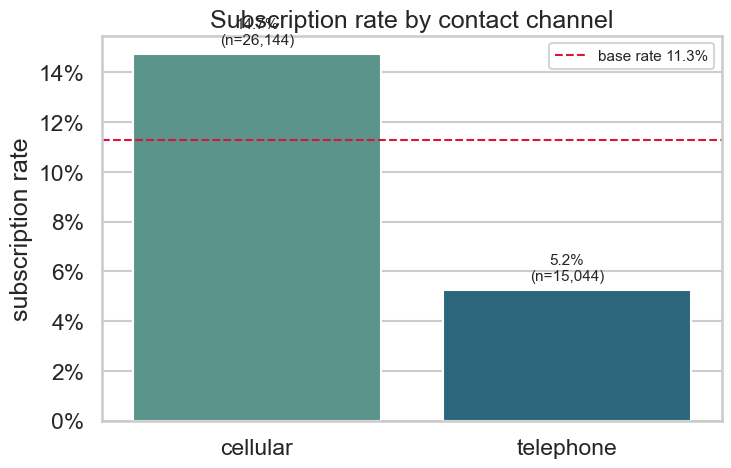

In [2]:
ch = rate_by("mart_campaign_outcomes", "contact_channel")
display(ch.style.format({"n": "{:,}", "n_subscribed": "{:,}", "rate": "{:.1%}"}))
gap = ch.iloc[0]["rate"] / ch.iloc[1]["rate"]
print(f"{ch.iloc[0]['contact_channel']} converts {gap:.1f}x the {ch.iloc[1]['contact_channel']} rate.")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ch, x="contact_channel", y="rate", hue="contact_channel",
            palette="crest", legend=False, ax=ax)
annotate_rate(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, r in ch.iterrows():
    ax.text(i, r["rate"] + 0.004, f"{r['rate']:.1%}\n(n={r['n']:,})", ha="center", fontsize=11)
ax.set_title("Subscription rate by contact channel")
ax.set_xlabel(""); ax.set_ylabel("subscription rate")
save(fig, "subscription_rate_by_channel.png")
plt.show()

_Caption: cellular contacts subscribe at 14.7% vs 5.2% for telephone — a **2.8x gap**. Tempting to call cellular 'better', but channel correlates with era and client type; whether the line type itself matters is a Day 5 question, not a conclusion._

## Subscription rate by contact month — and the volume skew

This dataset has a **heavy month skew**, so rate and volume are plotted together. Reading rate alone would badly mislead.

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


saved -> reports\figures\subscription_rate_by_month.png


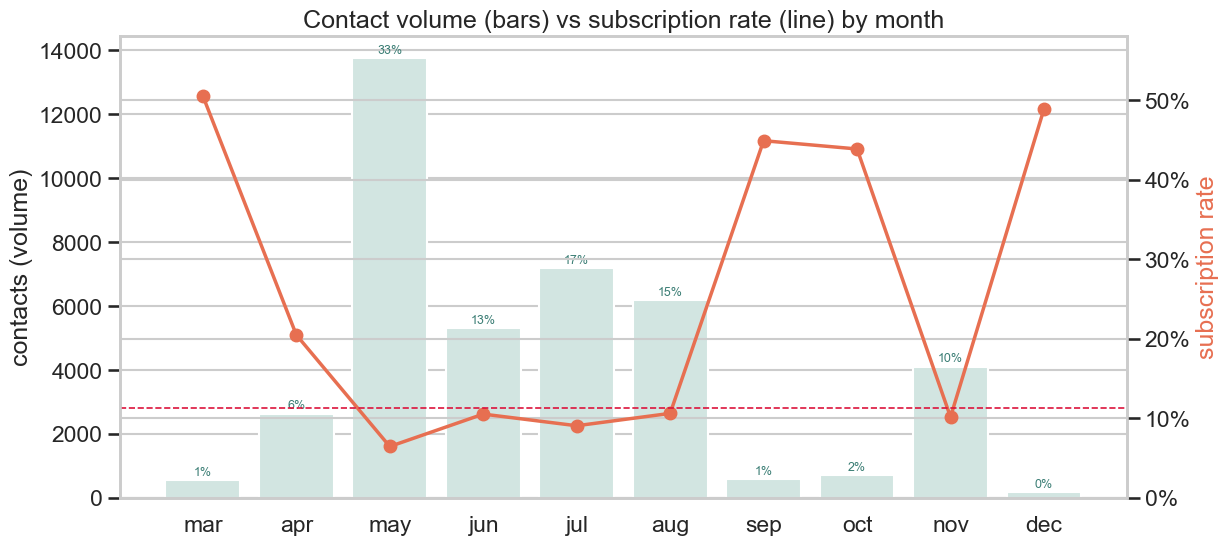

In [3]:
mo = client.query(f"""
    select contact_month,
           count(*) as n,
           avg(cast(subscribed as int64)) as rate
    from `{MARTS}.mart_campaign_outcomes`
    group by contact_month
""").to_dataframe()
cal = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
mo["contact_month"] = pd.Categorical(mo["contact_month"], categories=cal, ordered=True)
mo = mo.sort_values("contact_month").dropna(subset=["contact_month"]).reset_index(drop=True)
# Drop the never-used calendar months (jan/feb absent) so the bar slots and the
# rate line share the same integer x-positions and stay aligned.
mo["contact_month"] = mo["contact_month"].cat.remove_unused_categories()
mo["vol_share"] = mo["n"] / mo["n"].sum()

fig, ax1 = plt.subplots(figsize=(13, 6))
sns.barplot(data=mo, x="contact_month", y="n", color="#cfe8e3", ax=ax1)
ax1.set_ylabel("contacts (volume)"); ax1.set_xlabel("")
for i, r in mo.iterrows():
    ax1.text(i, r["n"] + 150, f"{r['vol_share']:.0%}", ha="center", fontsize=9, color="#3a7d74")
ax2 = ax1.twinx()
ax2.plot(range(len(mo)), mo["rate"], marker="o", color="#e76f51", linewidth=2.5)
ax2.axhline(BASE_RATE, color="crimson", linestyle="--", linewidth=1.2)
ax2.set_ylabel("subscription rate", color="#e76f51")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(pct))
ax2.set_ylim(0, mo["rate"].max() * 1.15)
ax1.set_title("Contact volume (bars) vs subscription rate (line) by month")
save(fig, "subscription_rate_by_month.png")
plt.show()

_Caption: the inverse relationship is the whole point. **May carries 33% of all contacts but converts at just 6.4% (below base); Mar/Sep/Oct/Dec convert at 44-51% on tiny volumes (<2% each).** Do NOT read this as 'call in March' — the low-volume months are almost certainly targeted follow-ups of warm leads, not a calendar effect. Volume vs effectiveness is a Day 5 confound._

## Subscription rate by number of contacts this campaign

**The central Day 4-5 question in one chart.**

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,contacts,n,rate
0,1,"17,642",13.0%
1,2,"10,570",11.5%
2,3,"5,341",10.7%
3,4,"2,651",9.4%
4,5,"1,599",7.5%
5,6+,"3,385",5.5%


saved -> reports\figures\subscription_rate_by_n_contacts.png


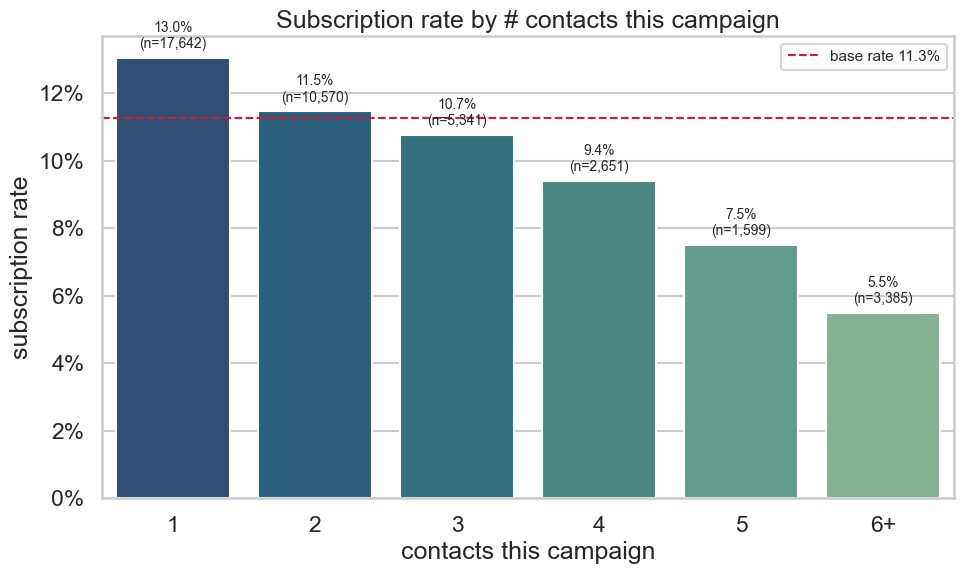

In [4]:
nc = client.query(f"""
    select case when n_contacts_this_campaign >= 6 then '6+'
                else cast(n_contacts_this_campaign as string) end as contacts,
           min(n_contacts_this_campaign) as ord,
           count(*) as n,
           avg(cast(subscribed as int64)) as rate
    from `{MARTS}.mart_campaign_outcomes`
    group by contacts
    order by ord
""").to_dataframe()
display(nc[["contacts", "n", "rate"]].style.format({"n": "{:,}", "rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=nc, x="contacts", y="rate", hue="contacts", palette="crest_r", legend=False, ax=ax)
annotate_rate(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, r in nc.iterrows():
    ax.text(i, r["rate"] + 0.003, f"{r['rate']:.1%}\n(n={r['n']:,})", ha="center", fontsize=10)
ax.set_title("Subscription rate by # contacts this campaign")
ax.set_xlabel("contacts this campaign"); ax.set_ylabel("subscription rate")
save(fig, "subscription_rate_by_n_contacts.png")
plt.show()

_Caption: the rate **falls monotonically** — 13.0% at 1 contact down to 5.5% at 6+. Counter-intuitively, more calls track *lower* success. Do NOT conclude 'calling hurts': this is almost certainly **reverse causation** — clients who say yes early leave the call list, so high contact counts accumulate among the hard 'no's. Persistence vs selection is the Day 5 task._

## Subscription rate by prior campaign outcome

The strongest predictor in the dataset — and the strongest confounder.

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,prior_outcome,n,n_subscribed,rate
0,success,"1,373",894,65.1%
1,failure,"4,252",605,14.2%
2,nonexistent,"35,563","3,141",8.8%


prior success converts at 65.1% -> 5.8x the base rate.


saved -> reports\figures\subscription_rate_by_prior_outcome.png


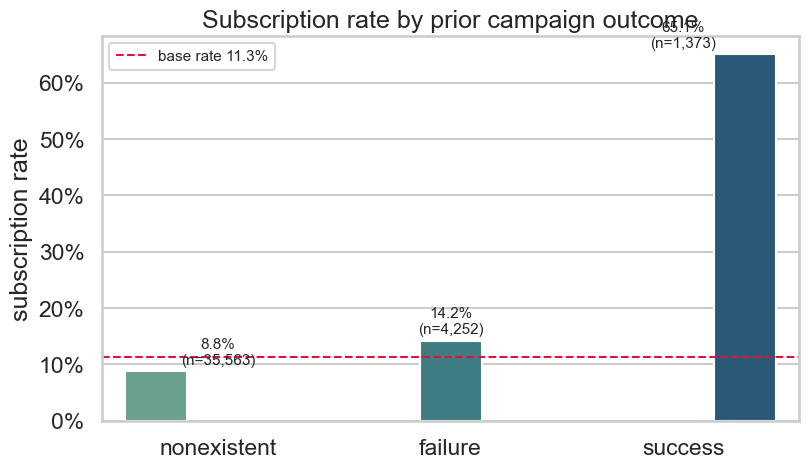

In [5]:
po = rate_by("mart_campaign_outcomes", "prior_outcome")
display(po.style.format({"n": "{:,}", "n_subscribed": "{:,}", "rate": "{:.1%}"}))
succ = po.loc[po["prior_outcome"] == "success", "rate"].iloc[0]
print(f"prior success converts at {succ:.1%} -> {succ/BASE_RATE:.1f}x the base rate.")

order = ["nonexistent", "failure", "success"]
po["prior_outcome"] = pd.Categorical(po["prior_outcome"], categories=order, ordered=True)
po = po.sort_values("prior_outcome").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=po, x="prior_outcome", y="rate", hue="prior_outcome",
            palette="crest", legend=False, ax=ax)
annotate_rate(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, r in po.iterrows():
    ax.text(i, r["rate"] + 0.012, f"{r['rate']:.1%}\n(n={r['n']:,})", ha="center", fontsize=11)
ax.set_title("Subscription rate by prior campaign outcome")
ax.set_xlabel(""); ax.set_ylabel("subscription rate")
save(fig, "subscription_rate_by_prior_outcome.png")
plt.show()

_Caption: clients whose **previous** campaign ended in success subscribe at **65.1% (n=1,373) — 5.8x the base rate**, vs 8.8% for those never previously contacted. This is the dominant signal AND the dominant confounder: is it the contact strategy, or a pre-existing willing relationship being re-harvested? Flagged hard for Day 5._

## Subscription rate by days since last contact

Previously-contacted clients only (n=1,515; the other 39,673 were never previously contacted, `days_since_last_contact IS NULL`).

C:\Users\PRASHANT\bank-campaign-causal-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,days_bucket,n,rate
0,0-3,541,65.2%
1,4-6,576,66.1%
2,7-9,142,61.3%
3,10+,256,57.0%


saved -> reports\figures\subscription_rate_by_days_since_last_contact.png


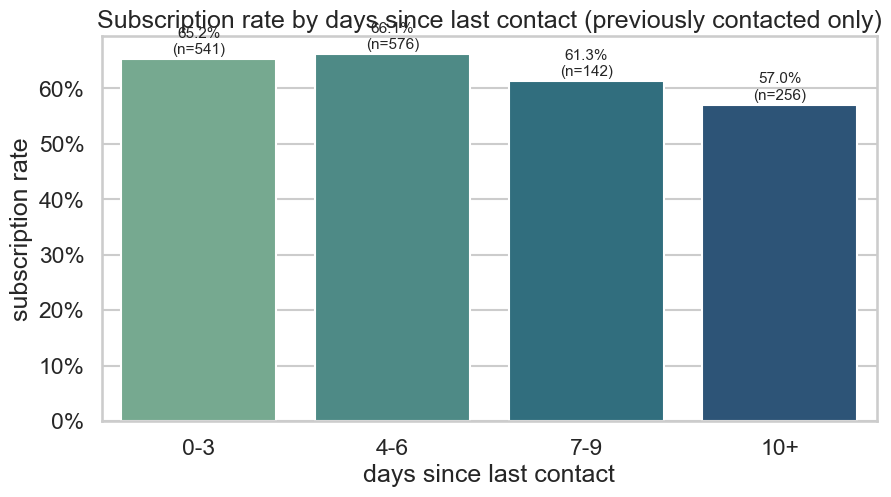

In [6]:
ds = client.query(f"""
    select case when days_since_last_contact <= 3 then '0-3'
                when days_since_last_contact <= 6 then '4-6'
                when days_since_last_contact <= 9 then '7-9'
                else '10+' end as days_bucket,
           min(days_since_last_contact) as ord,
           count(*) as n,
           avg(cast(subscribed as int64)) as rate
    from `{MARTS}.mart_campaign_outcomes`
    where was_previously_contacted
    group by days_bucket
    order by ord
""").to_dataframe()
display(ds[["days_bucket", "n", "rate"]].style.format({"n": "{:,}", "rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ds, x="days_bucket", y="rate", hue="days_bucket", palette="crest", legend=False, ax=ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(pct))
for i, r in ds.iterrows():
    ax.text(i, r["rate"] + 0.01, f"{r['rate']:.1%}\n(n={r['n']:,})", ha="center", fontsize=11)
ax.set_title("Subscription rate by days since last contact (previously contacted only)")
ax.set_xlabel("days since last contact"); ax.set_ylabel("subscription rate")
save(fig, "subscription_rate_by_days_since_last_contact.png")
plt.show()

_Caption: among the small previously-contacted pool, conversion is high across the board (57-66%) and drifts down as the gap widens — recent re-contacts (0-6 days) convert at ~65%, older ones (10+ days) at 57%. But this subgroup overlaps heavily with prior-success, so the level reflects *who* these clients are, not recency timing. Small n; correlation only._

---
Findings and the causal-question callout are in `docs/findings.md` -> **Section 1: The Subscription Landscape**.